# 03-1. 실험 모델의 영향요인과 오류분석

평가 항목 3(주요 영향변수·변수 간 상호작용, False Negative·False Positive가 집중되는 공정조건)에 답합니다. 02-3이 15분 모델의 오차·경보를 분석했다면, 이 노트북은 **02-4에서 같은 기준으로 비교한 실험 모델 전체**(시간 최대 분류기·Chronos-2·스태킹·LightGBM과 15분 모델)를 나란히 놓고 분석합니다.

| 절 | 분석 | 대상 | 근거 |
|---|---|---|---|
| 1 | 영향변수·상호작용(SHAP) | 시간 최대 피크 분류기(1시간 앞·하루 앞) | 이 노트북에서 실행 |
| 2 | 영향변수·정보의 효과 | 부록 파이프라인의 LightGBM·정보 시나리오 S0/S1/S2 | 부록 저장 결과 |
| 3 | FN·FP가 몰리는 조건 | 1시간 앞 경보 5가지(15분 규칙, Chronos-2 규칙, 분류기, 스태킹, 분위수 확률) | 02-4 저장 결과로 이 노트북에서 계산 |
| 4 | 조건별 예측 오차 | 1시간 앞·하루 앞 점예측 모델 | 02-4 저장 결과로 이 노트북에서 계산 |
| 5 | FN·FP 조건(부록) | 부록 최종 경보 | 부록 저장 결과 |

> 기준은 02-4와 같습니다(7/1 이후, 피크 188.7kW, 2~5주차 평가). SHAP은 '함께 나타난 관계'를 보여 줄 뿐 원인을 확인하는 방법은 아닙니다.

In [1]:
# [코드 E-01] 준비: 공통 함수, 정답·피처, 02-4의 시간별 예측·경보
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import hourly_utils as mu

font = mu.pu.set_korean_font()
pd.set_option('display.max_columns', 30)
F = mu.load_friend()
truth = mu.hourly_truth(F['slots'], F['days'])
m = mu.our_frame(F['days'])
X = {'A': mu.features(m, 'A'), 'B': mu.features(m, 'B')}
P = mu.OUT / 'preds'
pts = pd.read_parquet(P / 'h_point_preds.parquet')
alarm_a = pd.read_parquet(P / 'h_alarms_A.parquet')
label = {}
for tr in 'AB':
    label.update(dict(mu.pu.make_features(m, tr, 'S1')[1][['피처', '설명']].itertuples(index=False)))
label.update({'dt_op': '평일 가동일(생산계획)', 'dt_sat': '토요일 가동(생산계획)', 'dt_off': '휴일·비가동(생산계획)', 'prev_op': '전날 가동'})
print(f"피처: 1시간 앞 {X['A'].shape[1]}개, 하루 앞 {X['B'].shape[1]}개 | 02-4 시간별 예측 {pts.shape}, 경보 {alarm_a.shape}")

피처: 1시간 앞 26개, 하루 앞 24개 | 02-4 시간별 예측 (888, 18), 경보 (720, 9)


## 1. 영향변수와 상호작용 — 시간 최대 피크 분류기(SHAP)

02-4의 피크 분류기와 같은 설정(클래스 가중 LightGBM)으로, 7/1~9/14의 정답이 있는 모든 시간을 학습한 **설명용 모델**을 만들고 SHAP을 계산합니다. 평가용이 아니라 '어떤 정보가 피크 판단에 쓰였는가'를 보기 위한 모델입니다.

- 평균 |SHAP|: 그 변수가 피크 확률(로그 오즈)을 평균적으로 얼마나 움직였는지. 클수록 영향이 큽니다.
- 상호작용: 두 변수가 함께 있을 때만 생기는 몫(φij + φji)의 평균 절댓값입니다.

In [2]:
# [코드 E-02] 설명용 피크 분류기와 SHAP·상호작용 [표 E-01·E-02]
import lightgbm as lgb
import shap


def explain(Xt):
    ok = truth['valid'].reindex(Xt.index).fillna(False).to_numpy()
    Xv, yv = Xt[ok], truth['peak'].reindex(Xt.index)[ok].astype(int).to_numpy()
    mdl = lgb.LGBMClassifier(**mu.CLF_PARAMS, scale_pos_weight=(len(yv) - yv.sum()) / yv.sum(), subsample_freq=1,
                             random_state=42, n_jobs=mu.pu.N_THREADS, deterministic=True, force_row_wise=True,
                             verbose=-1).fit(Xv, yv)
    ex = shap.TreeExplainer(mdl)
    sv, iv = np.asarray(ex.shap_values(Xv)), np.asarray(ex.shap_interaction_values(Xv))
    sv = sv[..., 1] if sv.ndim == 3 else sv
    iv = iv[..., 1] if iv.ndim == 4 else iv
    return Xv, yv, sv, iv


imp, inter = [], []
for tr, name in [('A', '1시간 앞'), ('B', '하루 앞')]:
    Xv, yv, sv, iv = explain(X[tr])
    cols = list(Xv.columns)
    s = pd.Series(np.abs(sv).mean(0), index=cols).sort_values(ascending=False)
    imp += [{'예측': name, '순위': i + 1, '변수': c, '설명': label.get(c, c), '평균 |SHAP|': v}
            for i, (c, v) in enumerate(s.head(10).items())]
    pair = [(cols[i], cols[j], np.abs(iv[:, i, j] + iv[:, j, i]).mean()) for i in range(len(cols)) for j in range(i + 1, len(cols))]
    for a, b, v in sorted(pair, key=lambda x: -x[2])[:5]:
        inter.append({'예측': name, '변수 1': label.get(a, a), '변수 2': label.get(b, b), '상호작용 크기': v})
    print(f'{name}: 학습 {len(yv)}시간(피크 {int(yv.sum())}시간), 피처 {len(cols)}개')
E01, E02 = pd.DataFrame(imp), pd.DataFrame(inter)
mu.save_table(E01, 'e01_shap_importance'); mu.save_table(E02, 'e02_shap_interactions')
display(E01.round(3)); display(E02.round(3))

1시간 앞: 학습 1708시간(피크 149시간), 피처 26개


하루 앞: 학습 1708시간(피크 149시간), 피처 24개


,예측,순위,변수,설명,평균 |SHAP|
0,1시간 앞,1,y_lag1,1시간 전 시간 피크,1.189
1,1시간 앞,2,hour,대상 시각(0~23),1.101
2,1시간 앞,3,q4_lag1,직전 시간 마지막 15분 값,0.961
3,1시간 앞,4,y_lag24,24시간 전 시간 피크,0.747
4,1시간 앞,5,prod_day,"당일 생산량 일합계(전일 확정 가정, 결손일 NaN)",0.634
5,1시간 앞,6,q_slope_lag1,직전 시간 15분 값 4개의 기울기(kW/15분),0.553
6,1시간 앞,7,y_lag2,2시간 전 시간 피크,0.496
7,1시간 앞,8,y_lag168,168시간 전 시간 피크,0.480
8,1시간 앞,9,y_ma3,직전 3시간 평균,0.474
9,1시간 앞,10,q_min_lag1,직전 시간 15분 값 4개의 최소,0.465


,예측,변수 1,변수 2,상호작용 크기
0,1시간 앞,대상 시각(0~23),1시간 전 시간 피크,0.507
1,1시간 앞,대상 시각(0~23),직전 시간 마지막 15분 값,0.216
2,1시간 앞,1시간 전 시간 피크,직전 3시간 평균,0.186
3,1시간 앞,1시간 전 시간 피크,2시간 전 시간 피크,0.163
4,1시간 앞,1시간 전 시간 피크,24시간 전 시간 피크,0.160
5,하루 앞,대상 시각(0~23),최근 4주 같은 요일·시각 평균,0.434
6,하루 앞,대상 시각(0~23),14일 전 같은 시각,0.309
7,하루 앞,대상 시각(0~23),"당일 생산량 일합계(전일 확정 가정, 결손일 NaN)",0.286
8,하루 앞,14일 전 같은 시각,최근 4주 같은 요일·시각 평균,0.260
9,하루 앞,7일 전 같은 시각,최근 4주 같은 요일·시각 평균,0.260


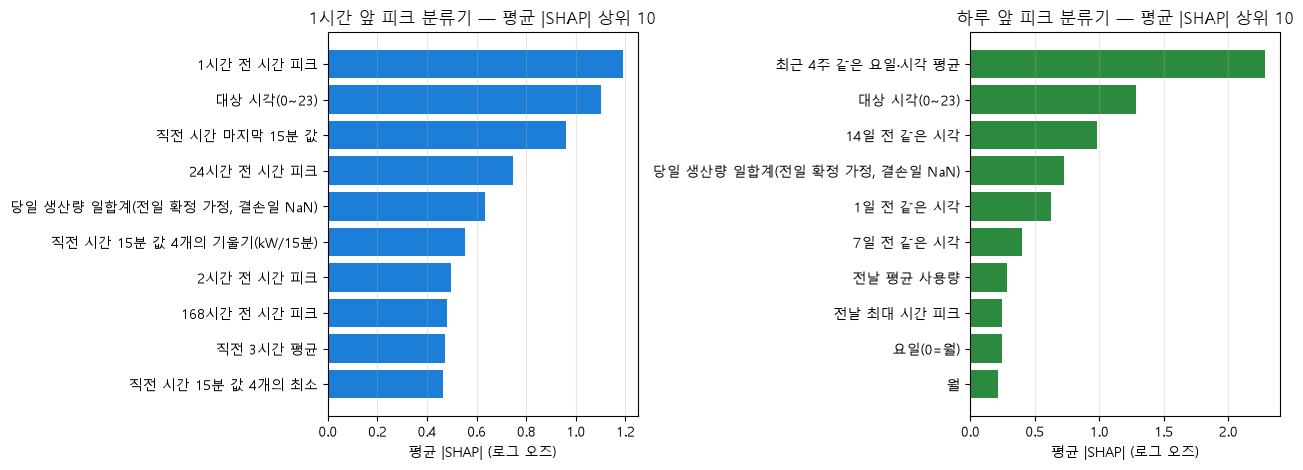

In [3]:
# [코드 E-03] 영향변수 상위 10개 [그림 E-01]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (name, g) in zip(axes, E01.groupby('예측', sort=False)):
    g = g.iloc[::-1]
    ax.barh(g['설명'], g['평균 |SHAP|'], color='#1c7ed6' if name == '1시간 앞' else '#2b8a3e')
    ax.set_title(f'{name} 피크 분류기 — 평균 |SHAP| 상위 10'); ax.set_xlabel('평균 |SHAP| (로그 오즈)')
    ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
mu.save_fig(fig, 'e01_shap_importance'); plt.show()

## 2. 영향변수와 정보의 효과 — 부록 파이프라인(저장 결과)

부록 파이프라인(1~8월 학습, 피크 기준은 학습 구간 상위 5%)에서 계산한 결과입니다. 학습 기간과 피크 기준이 이 노트북과 달라 **참고로** 나란히 봅니다.

- 회귀 LightGBM(시나리오 S1)의 SHAP 중요도 상위 5개와 상호작용 상위 5개
- 정보 시나리오: 같은 모델에 S0(달력·과거값) → S1(+당일 생산계획) → S2(+당일 가동 여부, 실제 전력에서 역산한 상한)를 넣었을 때 검증 MAE가 얼마나 줄어드는지(6 fold 평균)

In [4]:
# [코드 E-04] 부록 파이프라인의 SHAP·정보 시나리오 효과 [표 E-03·E-04]
K = mu.KIT / 'outputs' / 'tables'
rd = lambda n: pd.read_csv(K / n, encoding='utf-8-sig')
shp = pd.concat([rd(f'shap_importance_{tr}.csv').head(5).assign(예측=name)
                 for tr, name in [('A', '1시간 앞(트랙 A)'), ('B', '하루 앞(트랙 B)')]])
shp['설명'] = shp['feature'].map(label).fillna(shp['feature'])
E03 = shp[['예측', 'feature', '설명', 'mean_abs_shap']].rename(columns={'feature': '변수', 'mean_abs_shap': '평균 |SHAP| (kW)'})
it = rd('M37_shap_interactions.csv')
it['변수 1'], it['변수 2'] = it['feature_1'].map(label).fillna(it['feature_1']), it['feature_2'].map(label).fillna(it['feature_2'])
E04 = rd('M15_scenario_gain.csv')
mu.save_table(E03, 'e03_appendix_shap'); mu.save_table(E04, 'e04_appendix_scenario_gain')
display(E03.round(2))
display(it[['track', '변수 1', '변수 2', 'mean_abs_interaction']].rename(columns={'track': '트랙', 'mean_abs_interaction': '상호작용 크기 (kW)'}))
display(E04)

,예측,변수,설명,평균 |SHAP| (kW)
0,1시간 앞(트랙 A),q4_lag1,직전 시간 마지막 15분 값,29.64
1,1시간 앞(트랙 A),y_lag1,1시간 전 시간 피크,12.23
2,1시간 앞(트랙 A),y_lag168,168시간 전 시간 피크,6.69
3,1시간 앞(트랙 A),hour,대상 시각(0~23),3.16
4,1시간 앞(트랙 A),q_min_lag1,직전 시간 15분 값 4개의 최소,3.00
0,하루 앞(트랙 B),prod_day,"당일 생산량 일합계(전일 확정 가정, 결손일 NaN)",33.92
1,하루 앞(트랙 B),y_dow4w,최근 4주 같은 요일·시각 평균,13.10
2,하루 앞(트랙 B),hour,대상 시각(0~23),6.68
3,하루 앞(트랙 B),y_d7,7일 전 같은 시각,4.44
4,하루 앞(트랙 B),prev_day_max,전날 최대 시간 피크,3.01


,트랙,변수 1,변수 2,상호작용 크기 (kW)
0,A,3시간 전 시간 피크,직전 시간 마지막 15분 값,2.343
1,A,168시간 전 시간 피크,직전 시간 마지막 15분 값,2.059
2,A,대상 시각(0~23),직전 시간 마지막 15분 값,1.567
3,A,직전 시간 마지막 15분 값,직전 시간 15분 값 4개의 최소,1.410
4,A,24시간 전 시간 피크,168시간 전 시간 피크,1.393
5,B,최근 4주 같은 요일·시각 평균,"당일 생산량 일합계(전일 확정 가정, 결손일 NaN)",12.409
6,B,대상 시각(0~23),"당일 생산량 일합계(전일 확정 가정, 결손일 NaN)",8.092
7,B,월,"당일 생산량 일합계(전일 확정 가정, 결손일 NaN)",4.250
8,B,7일 전 같은 시각,최근 4주 같은 요일·시각 평균,2.800
9,B,대상 시각(0~23),최근 4주 같은 요일·시각 평균,2.250


,트랙,모델,S0,S1,S2,S0→S1 개선(%),S1→S2 개선(%)
0,A,AutoARIMA,14.233,14.030,14.278,1.4,-1.8
1,A,LightGBM,6.363,6.253,5.694,1.7,8.9
2,A,LightGBM 피크가중,7.036,6.879,6.206,2.2,9.8
3,A,LightGBM 분위수(q50),6.258,6.004,5.739,4.1,4.4
4,A,XGBoost,6.499,6.488,5.764,0.2,11.2
5,A,CatBoost,6.984,6.574,6.310,5.9,4.0
6,B,AutoARIMA,33.260,31.575,30.415,5.1,3.7
7,B,LightGBM,15.889,12.684,8.794,20.2,30.7
8,B,LightGBM 피크가중,16.330,12.441,8.880,23.8,28.6
9,B,LightGBM 분위수(q50),15.502,13.504,9.945,12.9,26.4


## 3. FN·FP가 몰리는 조건 — 1시간 앞 경보 5가지(2~5주차)

02-4에서 비교한 경보의 시간별 결정(경보 여부)을 조건별로 나눠, **놓친 피크(FN)**와 **헛경보(FP)**가 어디에 몰리는지 봅니다. 조건은 모두 예측 시점에 알 수 있는 운영 조건입니다.

| 조건 | 값 |
|---|---|
| 하루 종류 | 평일 가동·토요일·휴일(생산계획, 01-2) |
| 전날 | 전날 가동 / 전날 휴무(휴무 직후 첫날) |
| 시간대 | 00~07시, 08시(기동), 09~11시, 12시(점심), 13~16시, 17~23시 |
| 요일 | 월요일 / 화~금 / 주말 |

In [5]:
# [코드 E-05] 조건별 놓친 피크(FN)·헛경보(FP) [표 E-05·E-06]
A = alarm_a[alarm_a['ok']].join(pts[['하루종류', '전날가동', 'hour']])
h = A['hour'].to_numpy()
A['시간대'] = np.select([h < 8, h == 8, (h >= 9) & (h <= 11), h == 12, (h >= 13) & (h <= 16)],
                     ['00~07시', '08시(기동)', '09~11시', '12시(점심)', '13~16시'], '17~23시')
dow = A.index.dayofweek
A['요일'] = np.where(dow == 0, '월요일', np.where(dow < 5, '화~금', '주말'))
A['전날'] = np.where(A['전날가동'].astype(bool), '전날 가동', '전날 휴무(휴무 직후)')
METHODS = {'15분 모델: 점예측 ≥ 178.7': '15분 규칙', '시간 최대 Chronos-2 ≥ 178.7': 'Chronos-2 규칙',
           '시간 최대: 분류기': '분류기', '시간 최대: 스태킹': '스태킹', '시간 최대: Chronos-2 분위수 확률': '분위수 확률'}
fn_rows, fp_rows = [], []
for cond in ['하루종류', '전날', '시간대', '요일']:
    for val, g in A.groupby(cond):
        pk = g['peak'].astype(bool)
        fn = {'조건': cond, '값': val, '피크 시간': int(pk.sum())}
        fp = {'조건': cond, '값': val, '피크 아닌 시간': int((~pk).sum())}
        for col, short in METHODS.items():
            al = g[col].astype(bool)
            fn[short], fp[short] = int((pk & ~al).sum()), int((~pk & al).sum())
        fn_rows.append(fn); fp_rows.append(fp)
E05, E06 = pd.DataFrame(fn_rows), pd.DataFrame(fp_rows)
mu.save_table(E05, 'e05_fn_by_condition'); mu.save_table(E06, 'e06_fp_by_condition')
print('[표 E-05] 놓친 피크(FN) 수 — 조건별'); display(E05)
print('[표 E-06] 헛경보(FP) 수 — 조건별'); display(E06)

[표 E-05] 놓친 피크(FN) 수 — 조건별


,조건,값,피크 시간,15분 규칙,Chronos-2 규칙,분류기,스태킹,분위수 확률
0,하루종류,토요일,0,0,0,0,0,0
1,하루종류,평일가동,42,7,1,8,27,25
2,하루종류,휴일,0,0,0,0,0,0
3,전날,전날 가동,32,5,0,6,22,20
4,전날,전날 휴무(휴무 직후),10,2,1,2,5,5
5,시간대,00~07시,0,0,0,0,0,0
6,시간대,08시(기동),7,0,0,1,3,4
7,시간대,09~11시,17,5,1,2,11,10
8,시간대,12시(점심),0,0,0,0,0,0
9,시간대,13~16시,18,2,0,5,13,11


[표 E-06] 헛경보(FP) 수 — 조건별


,조건,값,피크 아닌 시간,15분 규칙,Chronos-2 규칙,분류기,스태킹,분위수 확률
0,하루종류,토요일,89,0,0,0,0,0
1,하루종류,평일가동,485,59,84,101,34,26
2,하루종류,휴일,84,0,0,0,0,0
3,전날,전날 가동,548,50,67,80,24,19
4,전날,전날 휴무(휴무 직후),110,9,17,21,10,7
5,시간대,00~07시,232,0,0,0,0,0
6,시간대,08시(기동),22,12,13,12,12,10
7,시간대,09~11시,70,22,39,43,18,15
8,시간대,12시(점심),29,0,0,3,0,0
9,시간대,13~16시,102,24,32,41,4,1


각 경보 방법에서 FN·FP가 가장 많이 몰린 조건을 뽑습니다. '비율'은 그 방법의 전체 FN(또는 FP) 중 그 조건이 차지하는 몫이고, '시간 비율'은 평가 시간 중 그 조건의 몫입니다. 비율이 시간 비율보다 크면 그 조건에 오류가 **몰려 있다**는 뜻입니다.

In [6]:
# [코드 E-06] 방법별 FN·FP 집중 조건 [표 E-07]
rows = []
for short in METHODS.values():
    for kind, T, base in [('놓친 피크(FN)', E05, '피크 시간'), ('헛경보(FP)', E06, '피크 아닌 시간')]:
        total = T.groupby('조건')[short].sum().iloc[0]
        for cond, g in T.groupby('조건', sort=False):
            top = g.loc[g[short].idxmax()]
            rows.append({'방법': short, '오류': kind, '전체 건수': int(total), '조건': cond, '가장 많은 값': top['값'],
                         '건수': int(top[short]), '비율': top[short] / total if total else np.nan,
                         '시간 비율': top[base] / g[base].sum()})
E07 = pd.DataFrame(rows)
E07['몰림(비율 ÷ 시간 비율)'] = E07['비율'] / E07['시간 비율']
mu.save_table(E07, 'e07_error_concentration')
display(E07.round(2))

,방법,오류,전체 건수,조건,가장 많은 값,건수,비율,시간 비율,몰림(비율 ÷ 시간 비율)
0,15분 규칙,놓친 피크(FN),7,하루종류,평일가동,7,1.00,1.00,1.00
1,15분 규칙,놓친 피크(FN),7,전날,전날 가동,5,0.71,0.76,0.94
2,15분 규칙,놓친 피크(FN),7,시간대,09~11시,5,0.71,0.40,1.76
3,15분 규칙,놓친 피크(FN),7,요일,화~금,5,0.71,0.76,0.94
4,15분 규칙,헛경보(FP),59,하루종류,평일가동,59,1.00,0.74,1.36
5,15분 규칙,헛경보(FP),59,전날,전날 가동,50,0.85,0.83,1.02
6,15분 규칙,헛경보(FP),59,시간대,13~16시,24,0.41,0.16,2.62
7,15분 규칙,헛경보(FP),59,요일,화~금,50,0.85,0.57,1.49
8,Chronos-2 규칙,놓친 피크(FN),1,하루종류,평일가동,1,1.00,1.00,1.00
9,Chronos-2 규칙,놓친 피크(FN),1,전날,전날 휴무(휴무 직후),1,1.00,0.24,4.20


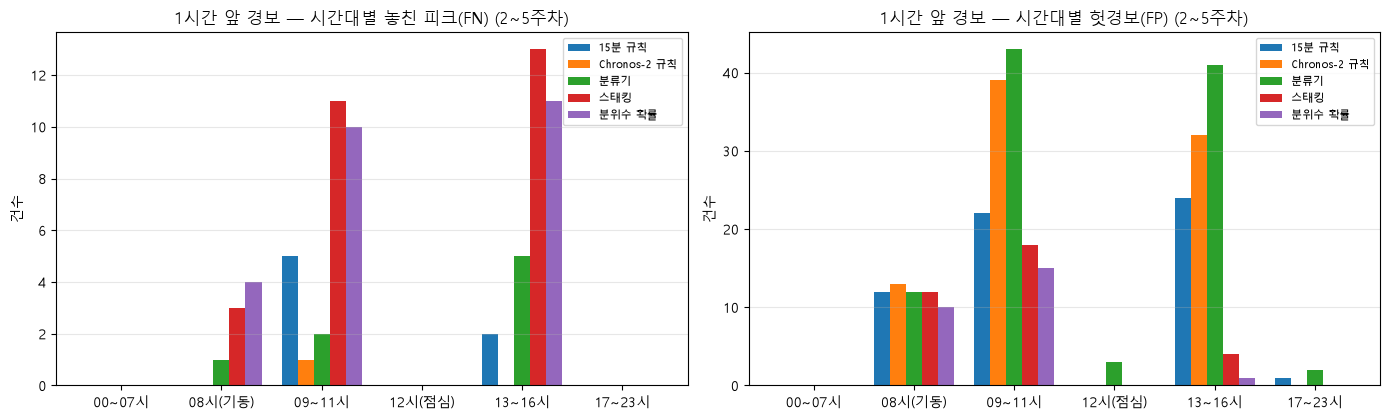

In [7]:
# [코드 E-07] 시간대별 FN·FP [그림 E-02]
order = ['00~07시', '08시(기동)', '09~11시', '12시(점심)', '13~16시', '17~23시']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), sharey=False)
for ax, (T, title) in zip(axes, [(E05, '놓친 피크(FN)'), (E06, '헛경보(FP)')]):
    g = T[T['조건'] == '시간대'].set_index('값').reindex(order)[list(METHODS.values())]
    g.plot.bar(ax=ax, width=0.8, rot=0)
    ax.set_title(f'1시간 앞 경보 — 시간대별 {title} (2~5주차)'); ax.set_xlabel(''); ax.set_ylabel('건수')
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
mu.save_fig(fig, 'e02_error_by_hourband'); plt.show()

## 4. 조건별 예측 오차 — 점예측 모델(시간 최대 MAE, 1~5주차)

02-4 [표 H-04]의 모델들을 하루 종류·전날·시간대로 나눠 MAE를 봅니다(02-4와 같은 시간, 정답과 15분 최종 예측이 모두 있는 시간). 어떤 모델이 어떤 운영 조건에서 약한지 보기 위한 표입니다.

In [8]:
# [코드 E-08] 조건별 시간 최대 MAE [표 E-08]
v = pts[pts['valid'] & pts['1시간 앞|15분 최종: 선형 회귀 + Chronos-2'].notna()].copy()
hh = v['hour'].to_numpy()
v['시간대'] = np.select([hh < 8, hh == 8, (hh >= 9) & (hh <= 11), hh == 12, (hh >= 13) & (hh <= 16)],
                     ['00~07시', '08시(기동)', '09~11시', '12시(점심)', '13~16시'], '17~23시')
v['전날'] = np.where(v['전날가동'].astype(bool), '전날 가동', '전날 휴무(휴무 직후)')
models = [c for c in pts.columns if '|' in c]
rows = []
for cond in ['하루종류', '전날', '시간대']:
    for val, g in v.groupby(cond):
        r = {'조건': cond, '값': val, '시간 수': len(g)}
        r.update({c: (g[c] - g['y']).abs().mean() for c in models})
        rows.append(r)
E08 = pd.DataFrame(rows)
mu.save_table(E08, 'e08_mae_by_condition')
display(E08.round(2))

,조건,값,시간 수,1시간 앞|15분 최종: 선형 회귀 + Chronos-2,1시간 앞|15분: 선형 회귀,1시간 앞|15분: Chronos-2(+가동 계획),1시간 앞|15분: LightGBM,1시간 앞|시간 최대: Chronos-2 zero-shot,1시간 앞|시간 최대: LightGBM(부록 STEP 3 설정),하루 앞|15분 최종: 기준 곡선,하루 앞|시간 최대: Chronos-2 + 공변량,하루 앞|시간 최대: LightGBM(부록 STEP 3 설정)
0,하루종류,토요일,113,3.91,4.02,4.47,4.36,4.92,4.85,5.35,6.25,6.95
1,하루종류,평일가동,647,6.89,7.12,7.16,7.53,6.54,9.80,8.25,7.71,11.62
2,하루종류,휴일,108,1.66,1.69,1.84,1.65,2.13,2.00,1.77,2.68,1.99
3,전날,전날 가동,724,5.49,5.77,5.67,6.04,5.16,7.49,6.37,5.93,9.05
4,전날,전날 휴무(휴무 직후),144,7.69,7.37,8.56,8.13,8.91,11.67,10.54,11.71,13.68
5,시간대,00~07시,288,4.98,4.89,5.47,5.10,4.95,6.50,5.47,5.05,7.26
6,시간대,08시(기동),36,8.50,7.93,9.56,9.84,7.73,13.33,8.96,8.55,13.50
7,시간대,09~11시,108,5.88,6.25,6.30,6.50,6.00,10.16,7.28,7.05,12.06
8,시간대,12시(점심),36,6.45,6.68,5.89,7.41,6.01,7.87,6.63,6.64,7.38
9,시간대,13~16시,148,6.64,7.53,6.69,7.77,6.29,9.50,8.56,8.74,13.18


In [9]:
# [코드 E-09] 조건별로 가장 정확한 모델 [표 E-09]
rows = []
for horizon in ['1시간 앞', '하루 앞']:
    cols = [c for c in models if c.startswith(horizon)]
    for _, r in E08.iterrows():
        d = pd.Series({c.split('|')[1]: r[c] for c in cols})
        rows.append({'예측': horizon, '조건': r['조건'], '값': r['값'], '시간 수': r['시간 수'],
                     '가장 정확한 모델': d.idxmin(), '최저 MAE': d.min(), '가장 부정확한 모델': d.idxmax(), '최고 MAE': d.max()})
E09 = pd.DataFrame(rows)
mu.save_table(E09, 'e09_best_model_by_condition')
display(E09.round(2))

,예측,조건,값,시간 수,가장 정확한 모델,최저 MAE,가장 부정확한 모델,최고 MAE
0,1시간 앞,하루종류,토요일,113,15분 최종: 선형 회귀 + Chronos-2,3.91,시간 최대: Chronos-2 zero-shot,4.92
1,1시간 앞,하루종류,평일가동,647,시간 최대: Chronos-2 zero-shot,6.54,시간 최대: LightGBM(부록 STEP 3 설정),9.80
2,1시간 앞,하루종류,휴일,108,15분: LightGBM,1.65,시간 최대: Chronos-2 zero-shot,2.13
3,1시간 앞,전날,전날 가동,724,시간 최대: Chronos-2 zero-shot,5.16,시간 최대: LightGBM(부록 STEP 3 설정),7.49
4,1시간 앞,전날,전날 휴무(휴무 직후),144,15분: 선형 회귀,7.37,시간 최대: LightGBM(부록 STEP 3 설정),11.67
5,1시간 앞,시간대,00~07시,288,15분: 선형 회귀,4.89,시간 최대: LightGBM(부록 STEP 3 설정),6.50
6,1시간 앞,시간대,08시(기동),36,시간 최대: Chronos-2 zero-shot,7.73,시간 최대: LightGBM(부록 STEP 3 설정),13.33
7,1시간 앞,시간대,09~11시,108,15분 최종: 선형 회귀 + Chronos-2,5.88,시간 최대: LightGBM(부록 STEP 3 설정),10.16
8,1시간 앞,시간대,12시(점심),36,15분: Chronos-2(+가동 계획),5.89,시간 최대: LightGBM(부록 STEP 3 설정),7.87
9,1시간 앞,시간대,13~16시,148,시간 최대: Chronos-2 zero-shot,6.29,시간 최대: LightGBM(부록 STEP 3 설정),9.50


## 5. FN·FP 조건 — 부록 파이프라인 최종 경보(저장 결과)

부록 파이프라인의 최종 경보(검증 F2~F6 합계, 피크 기준은 학습 구간 상위 5%)에서 FN·FP를 조건별로 센 결과입니다. 시각(hour)과 요일(dow, 0 = 월요일)별 상위 조건만 봅니다.

In [10]:
# [코드 E-10] 부록 파이프라인 FN·FP 조건 [표 E-10]
c32 = rd('M32_fn_fp_conditions.csv')
E10 = (c32.sort_values('건수', ascending=False).groupby(['track', 'type', '조건']).head(3)
       .sort_values(['track', 'type', '조건', '건수'], ascending=[True, True, True, False]))
mu.save_table(E10, 'e10_appendix_fn_fp')
display(E10.rename(columns={'track': '트랙', 'type': '오류'}).reset_index(drop=True))

,트랙,오류,조건,값,건수
0,A,FN,after_shutdown,False,28
1,A,FN,after_shutdown,True,9
2,A,FN,dow,1,10
3,A,FN,dow,0,9
4,A,FN,dow,4,6
...,...,...,...,...,...
56,B,FP,prod_bin,중간,28
57,B,FP,prod_bin,없음,21
58,B,FP,tou_load,최대부하,79
59,B,FP,tou_load,중간부하,27


## 6. 정리 — 영향요인과 오류가 몰리는 조건

모든 수치는 위 표에서 인용했습니다.

**① 주요 영향변수와 상호작용**
- **1시간 앞 피크 판단은 '직전 흐름'이 좌우합니다.** 설명용 분류기의 평균 |SHAP| 상위는 1시간 전 시간 피크(1.189), 대상 시각(1.101), 직전 시간 마지막 15분 값(0.961)이었습니다(표 E-01). 부록 회귀 모델에서도 직전 시간 마지막 15분 값(29.64kW)과 1시간 전 시간 피크(12.23kW)가 1·2위였습니다(표 E-03).
- **하루 앞 판단은 '같은 요일·시각의 과거 패턴 + 시각 + 생산계획'입니다.** 최근 4주 같은 요일·시각 평균(2.287), 대상 시각(1.284), 14일 전 같은 시각(0.985), 당일 생산량 일합계(0.729) 순이었습니다. 부록 회귀 모델에서는 당일 생산량 일합계가 1위(33.92kW)였습니다.
- **상호작용은 대부분 '시각'과 함께 나타났습니다.** 1시간 앞은 시각 × 1시간 전 시간 피크(0.507), 하루 앞은 시각 × 최근 4주 평균(0.434)이 가장 컸습니다(표 E-02). 같은 직전 값이라도 몇 시냐(기동·점심·교대)에 따라 피크 가능성이 달라진다는 뜻입니다.
- **정보의 효과**: 부록의 정보 시나리오에서 하루 앞 LightGBM의 검증 MAE는 당일 생산계획을 넣으면 20.2%, 당일 가동 여부까지 넣으면 추가로 30.7% 줄었습니다. 1시간 앞은 각각 1.7%·8.9%로 작았습니다(표 E-04).

**② False Negative·False Positive가 몰리는 조건(1시간 앞, 2~5주차)**
- **오류는 모두 평일 가동일에서 생겼습니다.** 피크 42시간이 모두 평일 가동일이었고, 토요일·휴일에는 어느 방법도 헛경보를 내지 않았습니다(표 E-05·E-06).
- **08시(기동)는 모든 방법이 피크와 비피크를 잘 가르지 못했습니다.** 피크가 아니었던 08시 22시간 중 헛경보가 10~13건이었습니다(방법별).
- **헛경보는 시간 최대 모델에서 09~11시, 15분 규칙에서 13~16시에 몰렸습니다.** 09~11시는 피크가 아닌 시간의 10.6%인데 Chronos-2 규칙 헛경보의 46%(39/84), 분류기의 43%(43/101)가 이 시간대였습니다(몰림 4.0~5.4배). 15분 규칙은 헛경보의 41%(24/59)가 13~16시였습니다(2.6배, 표 E-07).
- **놓친 피크는 방법마다 달랐습니다.** 15분 규칙은 7건 중 5건이 09~11시, 분류기는 8건 중 5건이 13~16시였습니다. Chronos-2 규칙은 1건만 놓쳤고, 휴무 직후 월요일 09~11시였습니다.

**③ 모델별로 강한 조건**
- 1시간 앞에서 시간 최대 Chronos-2는 평일 가동일(MAE 6.54), 08시 기동(7.73), 13~16시(6.29)에서 가장 정확했습니다. 15분 모델은 휴무 직후(선형 회귀 7.37), 야간(00~07시, 선형 회귀 4.89), 09~11시(최종 5.88)에서 가장 정확했습니다(표 E-09).
- 하루 앞에서는 시간 최대 Chronos-2 + 공변량이 평일 가동일(7.71)에서, 15분 기준 곡선이 휴무 직후(10.54)·13~16시(8.56)에서 가장 정확했습니다.
- 부록 설정을 그대로 쓴 LightGBM은 거의 모든 조건에서 가장 부정확했습니다.

**④ 현장에서 읽는 법**
- 경보가 가장 덜 믿을 만한 곳은 **평일 08시 기동과 09~11시**입니다. 04-1의 고정 규칙(평일 08~12시·13~16시에 배치형 설비를 돌리지 않음)이 바로 이 시간대를 다룹니다.
- 휴무 직후 첫날은 1시간 앞·하루 앞 모두 오차가 큰 조건이므로(1시간 앞 최저 MAE 7.37, 하루 앞 10.54) 주의일로 따로 관리할 근거가 됩니다(02-3·04-2의 '주의일'과 같은 조건).